<a href="https://colab.research.google.com/github/llShathaAlharbi/SDAIA-Computer-Vision-Program-/blob/main/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving basketball.jpg to basketball (1).jpg

image 1/1 /content/basketball (1).jpg: 640x480 1 person, 1 sports ball, 154.9ms
Speed: 6.5ms preprocess, 154.9ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 480)


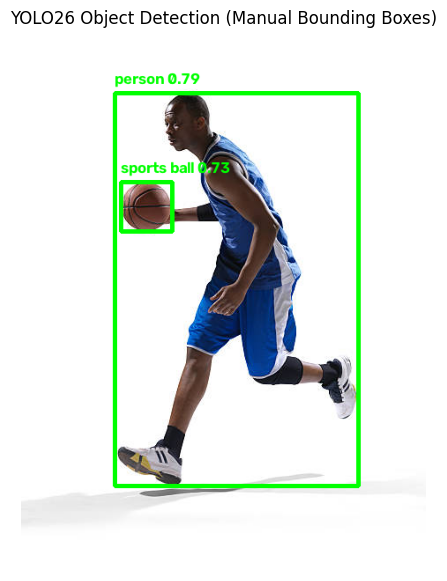

-----------------------------------------------------------------
Descriptive Summary: The scene contains 1 person(s), 1 sports ball(s).
-----------------------------------------------------------------


In [4]:
# Step 1: Upload an image for "basketball player with the ball in his hand"
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


# Step 2: Run YOLO26 model to give prediction of the content of the image
model = YOLO('yolo26n.pt')
results = model(image_path)


# Step 3: Apply custom confidence thresholding, plot bounding boxes manually, and write class on top
annotated_img = img_rgb.copy()
detected_classes = []
CONFIDENCE_THRESHOLD = 0.50

for result in results:
    for box in result.boxes:
        conf = float(box.conf[0])
        if conf >= CONFIDENCE_THRESHOLD:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls_id = int(box.cls[0])
            class_name = model.names[cls_id]
            detected_classes.append(class_name)

            cv2.rectangle(annotated_img, (x1, y1), (x2, y2), (0, 255, 0), 3)
            label = f"{class_name} {conf:.2f}"
            cv2.putText(annotated_img, label, (x1, max(y1 - 10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

plt.figure(figsize=(10, 7))
plt.imshow(annotated_img)
plt.axis('off')
plt.title('YOLO26 Object Detection (Manual Bounding Boxes)')
plt.show()


# Step 4: Programmatically generate a natural language descriptive summary below the image
counts = {}
for item in detected_classes:
    counts[item] = counts.get(item, 0) + 1

if counts:
    summary = ", ".join([f"{v} {k}(s)" for k, v in counts.items()])
    description = f"Descriptive Summary: The scene contains {summary}."
else:
    description = f"Descriptive Summary: No objects detected with confidence >= {CONFIDENCE_THRESHOLD}."

print("-" * 65)
print(description)
print("-" * 65)